# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


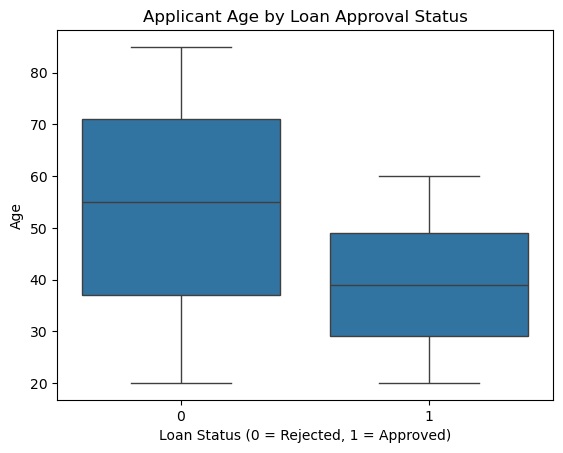

In [5]:
sns.boxplot(data=df, x='loan_status', y='person_age')

plt.title('Applicant Age by Loan Approval Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Age')

plt.show()

Applicant age appears to be related to loan approval decisions. Rejected applicants generally had higher ages and a wider age distribution, while approved applicants tended to be younger overall. This suggests age may be influencing the model’s decisions.

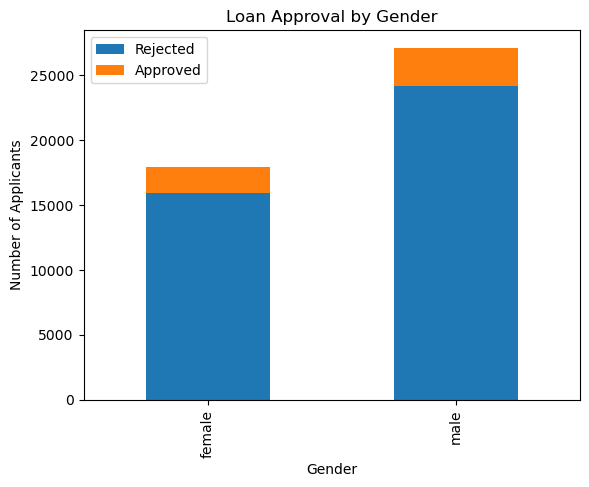

In [8]:
gender_approval = pd.crosstab(df['person_gender'], df['loan_status'])

gender_approval.plot(kind='bar', stacked=True)

plt.title('Loan Approval by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Applicants')
plt.legend(['Rejected', 'Approved'])

plt.show()

Gender does not appear to show a dramatic difference in loan approval outcomes based on raw applicant counts alone. While there are more male applicants overall, both genders show a similar pattern of having substantially more rejections than approvals. Gender may have some relationship to loan decisions, but the effect appears less pronounced than age.

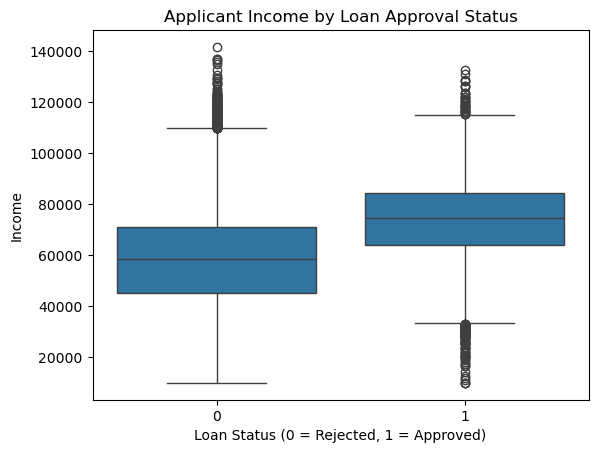

In [11]:
sns.boxplot(data=df, x='loan_status', y='person_income')

plt.title('Applicant Income by Loan Approval Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Income')

plt.show()

Applicant income appears to be strongly related to loan approval outcomes. Approved applicants generally had noticeably higher incomes, with a higher median and an overall upward-shifted distribution compared to rejected applicants. This suggests income is an important factor influencing the model’s approval decisions.

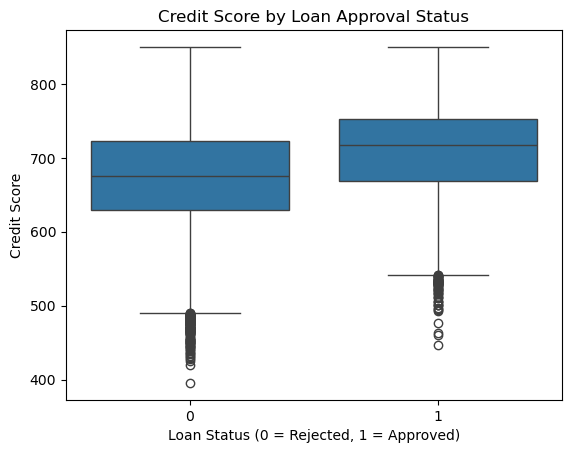

In [14]:
sns.boxplot(data=df, x='loan_status', y='credit_score')

plt.title('Credit Score by Loan Approval Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Credit Score')

plt.show()

Credit score appears to be strongly related to loan approval outcomes. Approved applicants generally had higher credit scores, with a noticeably higher median and an overall upward-shifted distribution compared to rejected applicants. Lower credit scores were more common among rejected applicants, suggesting credit score is an important factor in the model’s approval decisions.

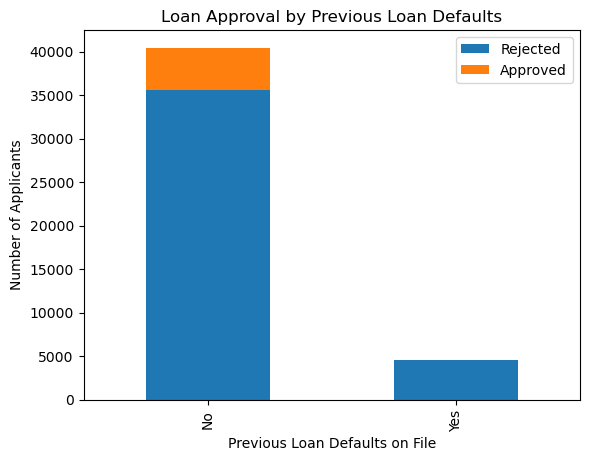

In [19]:
default_approval = pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status'])

default_approval.plot(kind='bar', stacked=True)

plt.title('Loan Approval by Previous Loan Defaults')
plt.xlabel('Previous Loan Defaults on File')
plt.ylabel('Number of Applicants')
plt.legend(['Rejected', 'Approved'])

plt.show()

Previous loan defaults appear to be one of the strongest factors influencing loan approval decisions. Applicants with prior loan defaults were overwhelmingly rejected, while applicants without previous defaults accounted for nearly all approved loans. This suggests the model heavily weighs prior default history when making approval decisions.

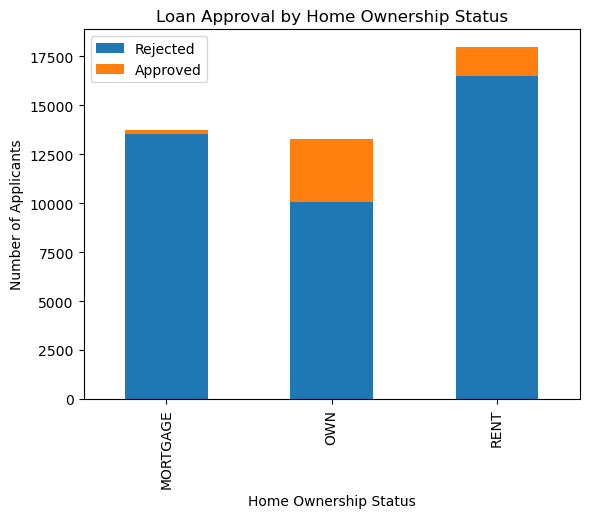

In [22]:
home_approval = pd.crosstab(df['person_home_ownership'], df['loan_status'])

home_approval.plot(kind='bar', stacked=True)

plt.title('Loan Approval by Home Ownership Status')
plt.xlabel('Home Ownership Status')
plt.ylabel('Number of Applicants')
plt.legend(['Rejected', 'Approved'])

plt.show()

Home ownership status appears to have a moderate relationship with loan approval outcomes. Applicants who owned their homes outright showed a noticeably higher proportion of approvals, while applicants who rented or had mortgages were rejected more often. This suggests home ownership status may influence the model’s decisions, though the relationship appears less strong than factors like income or previous loan defaults.

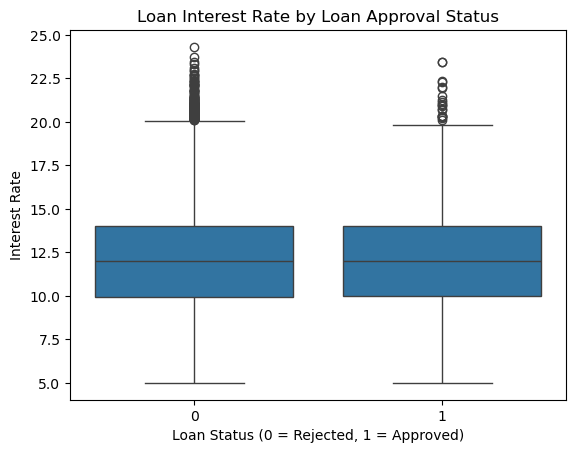

In [25]:
sns.boxplot(data=df, x='loan_status', y='loan_int_rate')

plt.title('Loan Interest Rate by Loan Approval Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Interest Rate')

plt.show()

Loan interest rate appears to have little relationship with loan approval outcomes. The approved and rejected applicant groups show nearly identical median interest rates, similar interquartile ranges, and overlapping overall distributions. This suggests loan interest rate is not a major factor influencing the model’s approval decisions.

Based on the visualizations, the strongest factors influencing loan approval decisions appear to be previous loan defaults, applicant income, and credit score, as these showed the clearest separation between approved and rejected applicants. Home ownership showed a moderate relationship, while loan interest rate appeared largely unrelated due to nearly identical distributions between groups.

Age appears to have a noticeable relationship with loan approval outcomes, with older applicants being rejected more often on average than younger applicants. Gender showed a weaker relationship, with no dramatic differences visible from the approval distributions.

Because age appears to influence approval outcomes, the financial institution may have reason to be concerned about potential legal scrutiny, especially given the complaint specifically mentioned age discrimination. While gender does not appear to strongly affect outcomes based on these visualizations, the observed relationship with age suggests the model should be reviewed for potential bias and fairness concerns.